Scenarios: 20 wind x 20 price x 4 SI = 1600 total
Scenario probability: pi = 0.000625

Building Gurobi model...
Set parameter Username
Set parameter LicenseID to value 2774416
Academic license - for non-commercial use only - expires 2027-02-03
Set parameter OutputFlag to value 1
Model: 0 variables | 0 constraints
Solving...
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) i7-10750H CPU @ 2.60GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 38400 rows, 76824 columns and 115200 nonzeros (Max)
Model fingerprint: 0xaece3383
Model has 69464 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [5e-06, 1e+02]
  Bounds range     [5e+02, 5e+02]
  RHS range        [1e-01, 5e+02]

Presolve removed 3680 rows and 7360 columns
Presolve time: 0.13s
Presolved: 34720 rows, 69464 columns, 104160 nonz

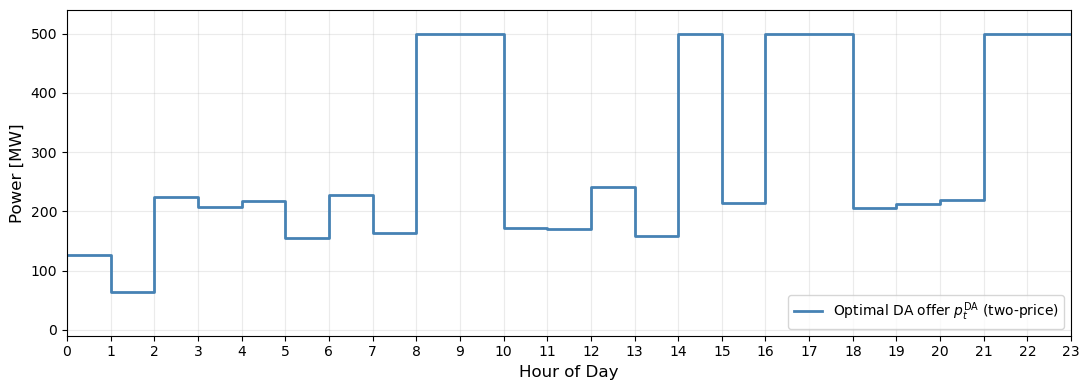

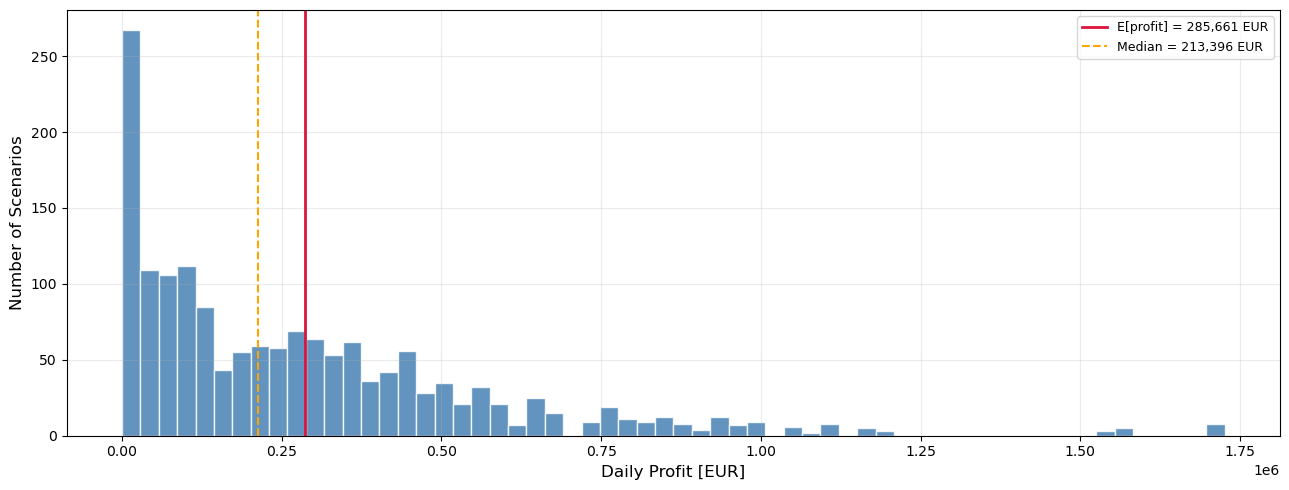

In [1]:
"""
Task 1.2 — Optimal Offering Strategy Under a Two-Price Balancing Scheme
========================================================================
Stochastic LP formulation following Lecture 8. Solver: Gurobi.

Combined scenarios: 20 wind x 20 price x 4 SI = 1,600  (pi = 1/1600)

KEY DIFFERENCE FROM 1.1 (one-price):
  Under one-price, ALL imbalances settle at the balancing price BP.
  Under two-price, settlement depends on whether the wind farm's
  imbalance is helpful or harmful to the system:

    Surplus (delta_up > 0):
      SI = 1 (system deficit)  → wind helped  → settled at BP = 1.25 * DA
      SI = 0 (system surplus)  → wind hurt     → settled at DA price only

    Deficit (delta_down > 0):
      SI = 1 (system deficit)  → wind hurt     → penalised at DA price only
      SI = 0 (system surplus)  → wind helped   → settled at BP = 0.85 * DA

Objective:
  max  sum_t sum_w  pi * [ lambda_tw^DA * p_t^DA
                           + r_tw^up   * delta_tw^up
                           - r_tw^down * delta_tw^down ]

  r_tw^up   = BP_tw   if SI_tw = 1  (surplus helps deficit system)
            = DA_tw   if SI_tw = 0  (surplus hurts surplus system)

  r_tw^down = DA_tw   if SI_tw = 1  (deficit hurts deficit system)
            = BP_tw   if SI_tw = 0  (deficit helps surplus system)

Variables and constraints are identical to Task 1.1.
"""

import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt
import itertools

# =============================================================================
# Configuration  (same as 1.1)
# =============================================================================
WIND_CSV   = 'wind_scenarios_DK2.csv'
PRICE_CSV  = 'price_scenarios_DK2.csv'
SI_CSV     = 'si_scenarios.csv'

P_NOM      = 500.0   # MW installed capacity
BP_DEFICIT = 1.25    # BP multiplier when SI = 1
BP_SURPLUS = 0.85    # BP multiplier when SI = 0

# =============================================================================
# Load scenario data  (identical to 1.1)
# =============================================================================
wind_df  = pd.read_csv(WIND_CSV,  index_col='hour')      # (24, 20)
price_df = pd.read_csv(PRICE_CSV, index_col='hour')      # (24, 20)
si_df    = pd.read_csv(SI_CSV,    index_col='scenario')  # (4,  24)

T       = 24
N_WIND  = wind_df.shape[1]          # 20
N_PRICE = price_df.shape[1]         # 20
N_SI    = si_df.shape[0]            # 4
N_SCEN  = N_WIND * N_PRICE * N_SI  # 1600
PI      = 1.0 / N_SCEN

print(f"Scenarios: {N_WIND} wind x {N_PRICE} price x {N_SI} SI = {N_SCEN} total")
print(f"Scenario probability: pi = {PI:.6f}")

# =============================================================================
# Build combined scenario matrices  shape: (T=24, N_SCEN=1600)
# Same Cartesian product as 1.1, but now we build TWO rate matrices
# instead of one symmetric bp_mat.
# =============================================================================
combos = list(itertools.product(range(N_WIND), range(N_PRICE), range(N_SI)))

wind_mat      = np.zeros((T, N_SCEN))
price_mat     = np.zeros((T, N_SCEN))
rate_up_mat   = np.zeros((T, N_SCEN))   # NEW: settlement rate for surplus
rate_down_mat = np.zeros((T, N_SCEN))   # NEW: settlement rate for deficit

for omega, (wi, pi_i, si_k) in enumerate(combos):
    wind_mat[:, omega]  = wind_df.iloc[:, wi].values
    price_mat[:, omega] = price_df.iloc[:, pi_i].values

# Cap negative DA prices to zero — negative prices cause rate matrices to go
# negative which makes the model unbounded. This is a deliberate modelling choice.
price_mat = np.maximum(price_mat, 0.0)

for omega, (wi, pi_i, si_k) in enumerate(combos):
    si_path             = si_df.iloc[si_k].values   # (24,) binary

    bp_path = price_mat[:, omega] * np.where(si_path == 1, BP_DEFICIT, BP_SURPLUS)

    # Two-price scheme — incentive-compatible formulation:
    # Harmful imbalances are penalised at BP; helpful imbalances settle at DA price.
    #
    # Surplus (delta_up):
    #   SI=1 (deficit)  -> helpful -> paid at DA price (no bonus)
    #   SI=0 (surplus)  -> harmful -> penalised at BP = 0.85*DA
    rate_up_mat[:, omega] = np.where(si_path == 1, price_mat[:, omega],
                                     price_mat[:, omega] * BP_SURPLUS)

    # Deficit (delta_down):
    #   SI=1 (deficit)  -> harmful -> penalised at BP = 1.25*DA
    #   SI=0 (surplus)  -> helpful -> charged at DA price (no bonus)
    rate_down_mat[:, omega] = np.where(si_path == 1, price_mat[:, omega] * BP_DEFICIT,
                                       price_mat[:, omega])

# =============================================================================
# Build and solve the stochastic LP with Gurobi
# =============================================================================
print("\nBuilding Gurobi model...")
m = gp.Model("task1_2_two_price")
m.setParam("OutputFlag", 1)

# First-stage: DA offer per hour (T,)
p_DA = m.addMVar(T, lb=0.0, ub=P_NOM, name="p_DA")

# Second-stage: surplus and deficit (T, N_SCEN)
# ub=P_NOM on delta_up is physically correct (can't produce more than installed capacity)
# and prevents unboundedness when rate_up > rate_down in some scenarios
delta_up   = m.addMVar((T, N_SCEN), lb=0.0, ub=P_NOM, name="delta_up")
delta_down = m.addMVar((T, N_SCEN), lb=0.0, name="delta_down")

# Objective coefficients
da_coeff      = (PI * price_mat).sum(axis=1)   # (T,)  — same as 1.1
up_coeff      = PI * rate_up_mat               # (T, N_SCEN)
down_coeff    = PI * rate_down_mat             # (T, N_SCEN)

m.setObjective(
    da_coeff @ p_DA
    + gp.quicksum(
        up_coeff[t, w] * delta_up[t, w] - down_coeff[t, w] * delta_down[t, w]
        for t in range(T) for w in range(N_SCEN)
    ),
    GRB.MAXIMIZE
)

# Imbalance constraints: identical to 1.1
for t in range(T):
    m.addConstr(
        delta_up[t, :] - delta_down[t, :] == wind_mat[t, :] - p_DA[t],
        name=f"imbalance_t{t}"
    )

print(f"Model: {m.NumVars:,} variables | {m.NumConstrs:,} constraints")
print("Solving...")
m.optimize()

if m.Status != GRB.OPTIMAL:
    raise RuntimeError(f"No optimal solution found. Gurobi status: {m.Status}")

# =============================================================================
# Extract results
# =============================================================================
p_DA_opt       = p_DA.X                   # (24,)
delta_up_opt   = delta_up.X               # (24, 1600)
delta_down_opt = delta_down.X             # (24, 1600)

# Per-scenario daily profit
da_revenue       = (price_mat    *  p_DA_opt[:, None]).sum(axis=0)
bal_revenue      = (rate_up_mat  *  delta_up_opt
                  - rate_down_mat * delta_down_opt).sum(axis=0)
scenario_profits = da_revenue + bal_revenue   # (1600,)
expected_profit  = scenario_profits.mean()

print(f"\nObjective value:      {m.ObjVal:,.2f} EUR")
print(f"Verified exp. profit: {expected_profit:,.2f} EUR")

# =============================================================================
# Console summary
# =============================================================================
print("\n" + "=" * 62)
print("  TASK 1.2 RESULTS -- TWO-PRICE SCHEME")
print("=" * 62)
print(f"\n  Expected profit      : {expected_profit:>13,.2f} EUR")
print(f"  Std deviation        : {scenario_profits.std():>13,.2f} EUR")
print(f"  Min profit           : {scenario_profits.min():>13,.2f} EUR")
print(f"  5th  percentile      : {np.percentile(scenario_profits,  5):>13,.2f} EUR")
print(f"  Median               : {np.median(scenario_profits):>13,.2f} EUR")
print(f"  95th percentile      : {np.percentile(scenario_profits, 95):>13,.2f} EUR")
print(f"  Max profit           : {scenario_profits.max():>13,.2f} EUR")

print(f"\n  -- Optimal DA offers per hour --")
print(f"  {'Hour':<6} {'p_DA (MW)':>10}  {'Mean wind':>10}  {'% Cap':>7}")
print("  " + "-" * 40)
for t in range(T):
    mw   = wind_mat[t, :].mean()
    flag = "  <- ZERO (withheld)" if p_DA_opt[t] < 0.5 else \
           "  <- FULL 500 MW"     if p_DA_opt[t] > P_NOM - 0.5 else ""
    print(f"  {t:<6} {p_DA_opt[t]:>10.2f}  {mw:>10.2f}  {p_DA_opt[t]/P_NOM*100:>6.1f}%{flag}")
print("=" * 62)

# =============================================================================
# Export results to CSV
# =============================================================================
pd.DataFrame({
    'hour'        : range(T),
    'p_DA_opt_MW' : p_DA_opt,
    'mean_wind_MW': wind_mat.mean(axis=1),
    'pct_capacity': p_DA_opt / P_NOM * 100,
}).to_csv('task1_2_DA_offers.csv', index=False)

pd.DataFrame({
    'scenario'  : range(N_SCEN),
    'profit_EUR': scenario_profits,
}).to_csv('task1_2_scenario_profits.csv', index=False)

print("\nSaved: task1_2_DA_offers.csv")
print("Saved: task1_2_scenario_profits.csv")

# =============================================================================
# Plot 1 -- Optimal DA offers vs mean wind
# =============================================================================
hours = np.arange(T)
fig, ax = plt.subplots(figsize=(11, 4))
ax.step(hours, p_DA_opt, where='post', color='steelblue', linewidth=2,
        label=r'Optimal DA offer $p_t^{\mathrm{DA}}$ (two-price)')
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Power [MW]', fontsize=12)
ax.set_xticks(hours)
ax.set_xlim(0, T - 1)
ax.set_ylim(-10, P_NOM + 40)
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('task1_2_DA_offers.pdf', dpi=150)
print("Saved: task1_2_DA_offers.pdf")

# =============================================================================
# Plot 2 -- Profit distribution
# =============================================================================
plt.figure(figsize=(13, 5))
plt.hist(scenario_profits, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(expected_profit,
            color='crimson', linewidth=2,
            label=f'E[profit] = {expected_profit:,.0f} EUR')
plt.axvline(np.median(scenario_profits),
            color='orange', linewidth=1.5, linestyle='--',
            label=f'Median = {np.median(scenario_profits):,.0f} EUR')
plt.xlabel('Daily Profit [EUR]', fontsize=12)
plt.ylabel('Number of Scenarios', fontsize=12)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('task1_2_profit_distribution.pdf', dpi=150)
print("Saved: task1_2_profit_distribution.pdf")
plt.show()


In [2]:
# =============================================================================
# Verification: compare balancing revenue under one-price vs two-price
# using the 1.1 optimal DA offers
# =============================================================================
p_DA_11 = pd.read_csv('task1_1_DA_offers.csv')['p_DA_opt_MW'].values

# Reconstruct bp_mat (one-price balancing price for each scenario)
bp_mat = np.zeros((T, N_SCEN))
for omega, (wi, pi_i, si_k) in enumerate(combos):
    si_path = si_df.iloc[si_k].values
    bp_mat[:, omega] = np.where(
        si_path == 1,
        price_mat[:, omega] * BP_DEFICIT,
        price_mat[:, omega] * BP_SURPLUS
    )

total_1price = 0
total_2price = 0
for t in range(T):
    delta_up_t   = np.maximum(wind_mat[t,:] - p_DA_11[t], 0)
    delta_down_t = np.maximum(p_DA_11[t] - wind_mat[t,:], 0)

    bal_1price = (bp_mat[t,:]       * delta_up_t - bp_mat[t,:]        * delta_down_t).mean()
    bal_2price = (rate_up_mat[t,:]  * delta_up_t - rate_down_mat[t,:] * delta_down_t).mean()

    total_1price += bal_1price
    total_2price += bal_2price
    print(f"Hour {t:2d}  1-price bal: {bal_1price:8.2f}  2-price bal: {bal_2price:8.2f}  diff: {bal_2price - bal_1price:8.2f}")

print(f"\nTotal balancing revenue difference (2-price minus 1-price): {total_2price - total_1price:,.2f} EUR")

Hour  0  1-price bal:  9605.49  2-price bal:  8461.98  diff: -1143.51
Hour  1  1-price bal: 10147.26  2-price bal:  8492.82  diff: -1654.45
Hour  2  1-price bal: -14404.84  2-price bal: -16110.67  diff: -1705.84
Hour  3  1-price bal: -13710.77  2-price bal: -15334.42  diff: -1623.64
Hour  4  1-price bal: -13909.77  2-price bal: -15556.97  diff: -1647.21
Hour  5  1-price bal:  9815.74  2-price bal:  8647.20  diff: -1168.54
Hour  6  1-price bal: -21608.14  2-price bal: -24167.00  diff: -2558.86
Hour  7  1-price bal: 17201.00  2-price bal: 15153.26  diff: -2047.74
Hour  8  1-price bal: -25604.33  2-price bal: -30122.74  diff: -4518.41
Hour  9  1-price bal: -22339.06  2-price bal: -26281.24  diff: -3942.19
Hour 10  1-price bal: 15162.58  2-price bal: 13357.51  diff: -1805.07
Hour 11  1-price bal: 13741.29  2-price bal: 12105.42  diff: -1635.87
Hour 12  1-price bal: -17174.87  2-price bal: -19208.74  diff: -2033.87
Hour 13  1-price bal: 11064.55  2-price bal:  9747.34  diff: -1317.21
Hour 1

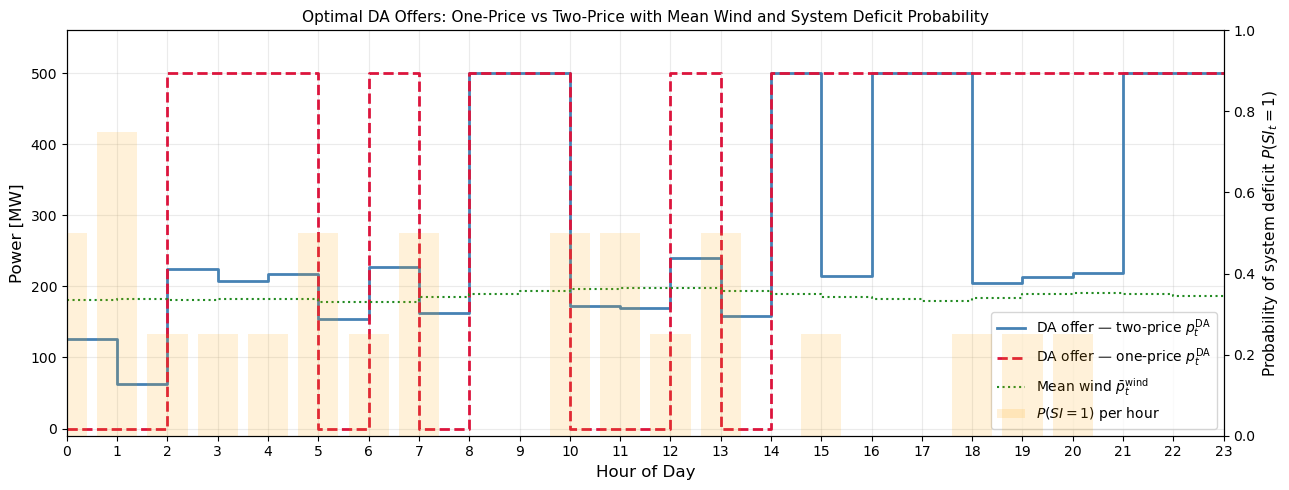

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load 1.1 DA offers from CSV
p_DA_opt_1p = pd.read_csv('task1_1_DA_offers.csv')['p_DA_opt_MW'].values

# Build SI matrix from existing variables (already in memory from 1.2 cell)
si_mat = np.zeros((T, N_SCEN))
for omega, (wi, pi_i, si_k) in enumerate(combos):
    si_mat[:, omega] = si_df.iloc[si_k].values

# SI=1 probability per hour
si_prob   = si_mat.mean(axis=1)   # (24,)
mean_wind = wind_mat.mean(axis=1) # (24,)

hours = np.arange(T)

fig, ax1 = plt.subplots(figsize=(13, 5))

# --- Primary axis: power [MW] ---
ax1.step(hours, p_DA_opt,    where='post', color='steelblue',   linewidth=2,
         label=r'DA offer — two-price $p_t^{\mathrm{DA}}$')
ax1.step(hours, p_DA_opt_1p, where='post', color='crimson',     linewidth=2,
         linestyle='--', label=r'DA offer — one-price $p_t^{\mathrm{DA}}$')
ax1.step(hours, mean_wind,   where='post', color='forestgreen', linewidth=1.5,
         linestyle=':', label=r'Mean wind $\bar{p}_t^{\mathrm{wind}}$')

ax1.set_xlabel('Hour of Day', fontsize=12)
ax1.set_ylabel('Power [MW]', fontsize=12)
ax1.set_xlim(0, T - 1)
ax1.set_ylim(-10, P_NOM + 60)
ax1.set_xticks(hours)
ax1.grid(True, alpha=0.25)

# --- Secondary axis: SI=1 probability ---
ax2 = ax1.twinx()
ax2.bar(hours, si_prob, alpha=0.15, color='orange', width=0.8,
        label=r'$P(SI=1)$ per hour')
ax2.set_ylabel(r'Probability of system deficit $P(SI_{t}=1)$', fontsize=11)
ax2.set_ylim(0, 1.0)

# --- Combined legend ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc='best')

plt.title('Optimal DA Offers: One-Price vs Two-Price with Mean Wind and System Deficit Probability',
          fontsize=11)
plt.tight_layout()
plt.savefig('task1_2_comparison_plot.pdf', dpi=150)
plt.show()